# Align Angle Force Plugin — Demo

This notebook demonstrates the `hoomd.align_angle.Align` force, which aligns an
oriented particle's **body-frame x-axis** to the direction defined by two guide
particles using the potential:

$$U = \frac{k}{2}\left(1 - \hat{n} \cdot \hat{d}\right)$$

where $\hat{d} = (\mathbf{r}_k - \mathbf{r}_i)/|\mathbf{r}_k - \mathbf{r}_i|$
and $\hat{n} = \mathrm{rotate}(q_j, \hat{x})$.

We'll simulate a short chain of 5 particles where:
- Particles 0, 2: guide particles (define the target direction)
- Particle 1: oriented particle (aligns to guides)
- Particles 3, 4: another pair of guides for a second oriented particle

Then we run Langevin dynamics and watch the orientations converge.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import hoomd
from hoomd import align_angle

print("HOOMD version:", hoomd.version.version)
print("Device:", hoomd.device.auto_select())

HOOMD version: 5.3.1
Device: <hoomd.device.GPU object at 0x7fdbc51e3fb0>


## 1. Set up the system

We create **3 particles** connected by one angle group `(0, 1, 2)`:
- Particles 0, 2 are **guide particles** placed along the x-axis
- Particle 1 is the **oriented particle** whose body-axis we want to align

We deliberately start particle 1 with a random orientation so we can
watch it relax toward the $\hat{x}$ direction.

In [2]:
device = hoomd.device.auto_select()

# --- Simulation parameters ---
K = 20.0        # spring constant
kT = 1.0        # thermal energy
dt = 0.005      # time step
N_steps = 20000 # total steps
log_every = 100 # logging period

# --- Build snapshot ---
snap = hoomd.Snapshot(device.communicator)
if snap.communicator.rank == 0:
    snap.configuration.box = [30, 30, 30, 0, 0, 0]
    snap.particles.N = 3
    snap.particles.types = ["Guide", "Oriented"]
    snap.particles.typeid[:] = [0, 1, 0]

    # Guides along x, oriented at origin
    snap.particles.position[0] = [-2.0, 0.0, 0.0]  # i
    snap.particles.position[1] = [ 0.0, 0.0, 0.0]  # j (oriented)
    snap.particles.position[2] = [ 2.0, 0.0, 0.0]  # k
    # => d_hat = (1, 0, 0)

    # Start particle 1 with orientation pointing along z (90° away from target)
    # Quaternion for 90° rotation around y: (cos45, 0, sin45, 0)
    c = np.cos(np.pi / 4)
    s = np.sin(np.pi / 4)
    snap.particles.orientation[0] = [1, 0, 0, 0]
    snap.particles.orientation[1] = [c, 0, -s, 0]  # body x-axis → lab -z
    snap.particles.orientation[2] = [1, 0, 0, 0]

    # Moment of inertia for particle 1 (needed for rotational dynamics)
    snap.particles.moment_inertia[1] = [1.0, 1.0, 1.0]
    snap.particles.mass[:] = 1.0

    # One angle group
    snap.angles.N = 1
    snap.angles.types = ["align"]
    snap.angles.typeid[0] = 0
    snap.angles.group[0] = (0, 1, 2)

print("Snapshot ready.  d_hat = (1, 0, 0)")
print(f"Initial body-axis of particle 1: rotate(q, x̂) ≈ (0, 0, -1)")
print(f"K = {K}, kT = {kT}, dt = {dt}, N_steps = {N_steps}")

Snapshot ready.  d_hat = (1, 0, 0)
Initial body-axis of particle 1: rotate(q, x̂) ≈ (0, 0, -1)
K = 20.0, kT = 1.0, dt = 0.005, N_steps = 20000


## 2. Build simulation & run

We use Langevin dynamics so that the oriented particle thermalizes while the
aligning torque tries to rotate it into alignment. We freeze the guide
particles by giving them zero moment of inertia (no rotational DOF) and
setting them in a group that doesn't integrate — but to keep things simple,
we just integrate everyone and pin the guides with `hoomd.md.force.Constant`
zero forces (they're free to move, but with no force they stay put).

We log the orientation of particle 1 every `log_every` steps.

In [3]:
sim = hoomd.Simulation(device=device, seed=42)
sim.create_state_from_snapshot(snap)

# --- Forces ---
align_force = align_angle.Align()
align_force.params["align"] = dict(k=K)

# --- Integrator: only integrate the Oriented particle, guides stay frozen ---
oriented_filter = hoomd.filter.Type(["Oriented"])
langevin = hoomd.md.methods.Langevin(filter=oriented_filter, kT=kT)
integrator = hoomd.md.Integrator(dt=dt, methods=[langevin], forces=[align_force])
integrator.integrate_rotational_dof = True   # MUST enable rotational DOF integration
sim.operations.integrator = integrator

# --- Logging ---
timesteps = []
cos_thetas = []
energies_log = []
orientations_log = []

def quat_rotate(q, v):
    """Rotate vector v by quaternion q = (s, vx, vy, vz)."""
    s, qv = q[0], np.array(q[1:])
    return v + 2 * s * np.cross(qv, v) + 2 * np.cross(qv, np.cross(qv, v))

d_hat = np.array([1.0, 0.0, 0.0])
e_x = np.array([1.0, 0.0, 0.0])

sim.run(0)

# Log the initial state (t=0)
with sim.state.cpu_local_snapshot as s:
    q = np.array(s.particles.orientation[1])
    n_hat = quat_rotate(q, e_x)
timesteps.append(0)
cos_thetas.append(np.dot(n_hat, d_hat))
energies_log.append(align_force.energies.sum() if align_force.energies is not None else 0)
orientations_log.append(n_hat.copy())

# Fine logging for first 500 steps to see transient
for _ in range(500):
    sim.run(1)
    with sim.state.cpu_local_snapshot as s:
        q = np.array(s.particles.orientation[1])
        n_hat = quat_rotate(q, e_x)
    timesteps.append(sim.timestep)
    cos_thetas.append(np.dot(n_hat, d_hat))
    energies_log.append(align_force.energies.sum() if align_force.energies is not None else 0)
    orientations_log.append(n_hat.copy())

# Coarse logging for the rest
remaining = N_steps - 500
for _ in range(remaining // log_every):
    sim.run(log_every)
    with sim.state.cpu_local_snapshot as s:
        q = np.array(s.particles.orientation[1])
        n_hat = quat_rotate(q, e_x)
    timesteps.append(sim.timestep)
    cos_thetas.append(np.dot(n_hat, d_hat))
    energies_log.append(align_force.energies.sum() if align_force.energies is not None else 0)
    orientations_log.append(n_hat.copy())

timesteps = np.array(timesteps)
cos_thetas = np.array(cos_thetas)
energies_log = np.array(energies_log)
orientations_log = np.array(orientations_log)

print(f"Simulation complete: {sim.timestep} steps")
print(f"Initial cos(θ) = {cos_thetas[0]:.4f}")
print(f"Final   cos(θ) = {cos_thetas[-1]:.4f}  (target = 1.0)")

Simulation complete: 20000 steps
Initial cos(θ) = 0.0000
Final   cos(θ) = 0.8158  (target = 1.0)


## 3. Visualize: Alignment over time

The cosine of the angle between the body-axis $\hat{n}$ and the target direction
$\hat{d}$ should converge toward 1.0 (perfect alignment). At $kT > 0$ there will
be thermal fluctuations around the minimum.

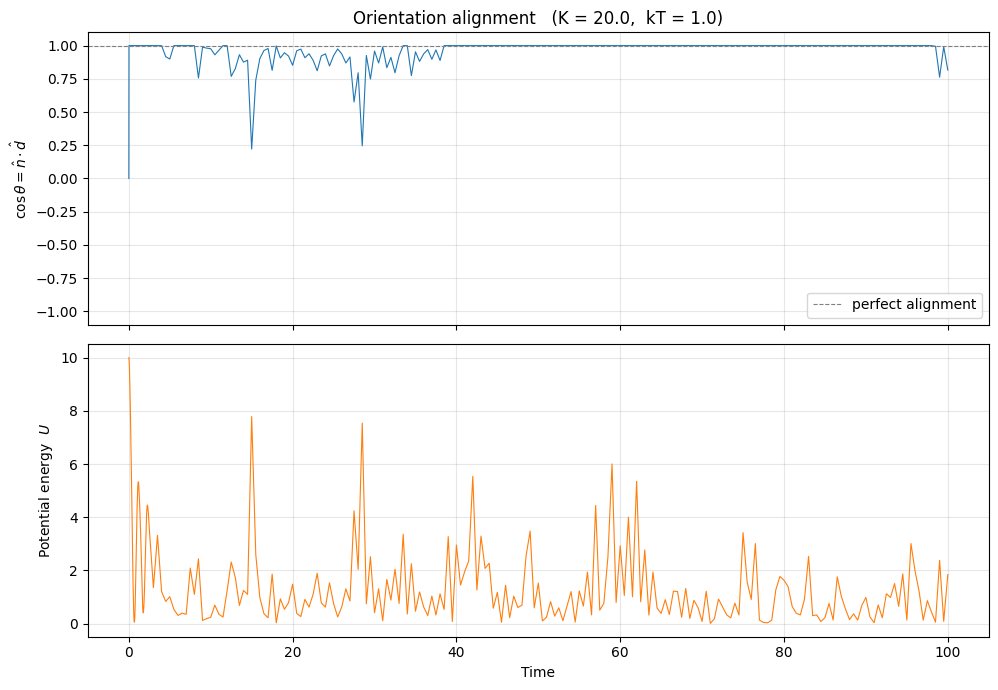

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# --- cos(θ) vs time ---
ax = axes[0]
ax.plot(timesteps * dt, cos_thetas, lw=0.8, color="C0")
ax.axhline(1.0, ls="--", color="gray", lw=0.8, label="perfect alignment")
ax.set_ylabel(r"$\cos\theta = \hat{n} \cdot \hat{d}$")
ax.set_title(f"Orientation alignment   (K = {K},  kT = {kT})")
ax.legend(loc="lower right")
ax.set_ylim(-1.1, 1.1)
ax.grid(alpha=0.3)

# --- Energy vs time ---
ax = axes[1]
ax.plot(timesteps * dt, energies_log, lw=0.8, color="C1")
ax.set_ylabel("Potential energy  $U$")
ax.set_xlabel("Time")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Body-axis trajectory on the unit sphere

We plot the 3 components of $\hat{n}$ over time. At equilibrium,
$n_x \approx 1$ with small thermal fluctuations in $n_y$ and $n_z$.

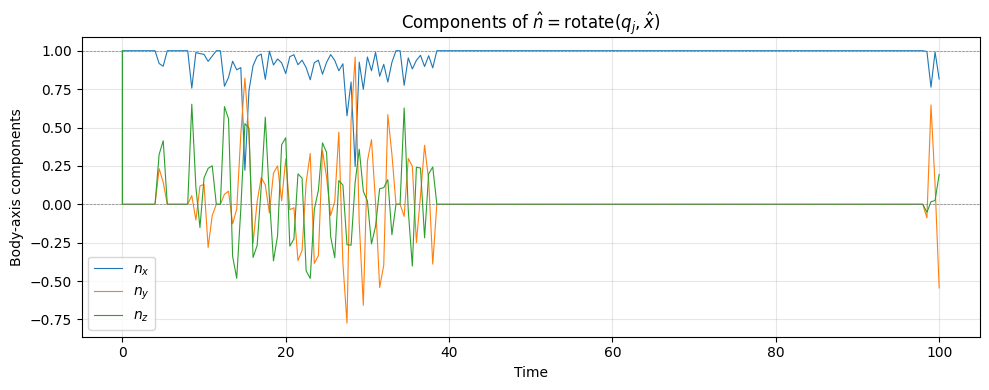

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
time = timesteps * dt
ax.plot(time, orientations_log[:, 0], label=r"$n_x$", lw=0.8)
ax.plot(time, orientations_log[:, 1], label=r"$n_y$", lw=0.8)
ax.plot(time, orientations_log[:, 2], label=r"$n_z$", lw=0.8)
ax.axhline(1, ls="--", color="gray", lw=0.5)
ax.axhline(0, ls="--", color="gray", lw=0.5)
ax.set_xlabel("Time")
ax.set_ylabel("Body-axis components")
ax.set_title(r"Components of $\hat{n} = \mathrm{rotate}(q_j, \hat{x})$")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Distribution of $\cos\theta$ at equilibrium

We take the last half of the trajectory (after the initial relaxation) and
histogram $\cos\theta$. For a harmonic-cosine potential at temperature
$kT$, the distribution should be peaked near 1.

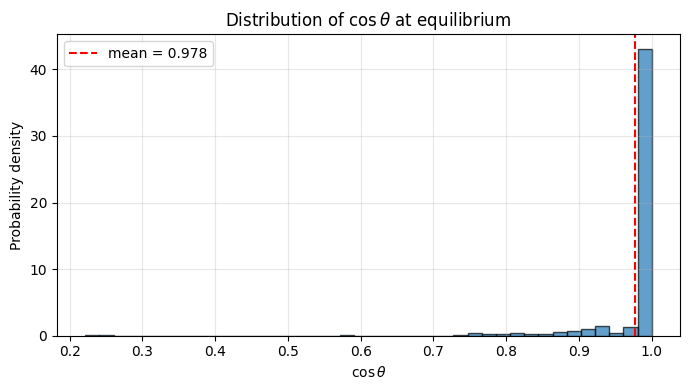

Equilibrium ⟨cos θ⟩ = 0.9775 ± 0.0769
Expected ⟨cos θ⟩ ≈ 1 - kT/K = 0.9500  (high-K approximation)


In [6]:
# Take equilibrated portion (last 50%)
equil = cos_thetas[len(cos_thetas) // 2 :]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(equil, bins=40, density=True, alpha=0.7, edgecolor="black", lw=0.5)
ax.axvline(equil.mean(), color="red", ls="--", lw=1.5, label=f"mean = {equil.mean():.3f}")
ax.set_xlabel(r"$\cos\theta$")
ax.set_ylabel("Probability density")
ax.set_title(r"Distribution of $\cos\theta$ at equilibrium")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Equilibrium ⟨cos θ⟩ = {equil.mean():.4f} ± {equil.std():.4f}")
print(f"Expected ⟨cos θ⟩ ≈ 1 - kT/K = {1 - kT/K:.4f}  (high-K approximation)")

## 6. Parameter sweep: varying K

We run several short simulations with different spring constants $K$ and
compare the alignment dynamics. Higher $K$ should produce faster alignment
and tighter fluctuations around the minimum.

In [7]:
K_values = [2.0, 5.0, 20.0, 50.0]
sweep_steps = 10000
sweep_log_every = 50

results = {}

for K_val in K_values:
    sim_sweep = hoomd.Simulation(device=device, seed=123)
    sim_sweep.create_state_from_snapshot(snap)

    af = align_angle.Align()
    af.params["align"] = dict(k=K_val)

    lang = hoomd.md.methods.Langevin(
        filter=hoomd.filter.Type(["Oriented"]), kT=kT
    )
    integ = hoomd.md.Integrator(dt=dt, methods=[lang], forces=[af])
    integ.integrate_rotational_dof = True
    sim_sweep.operations.integrator = integ

    ts_list, ct_list = [], []
    sim_sweep.run(0)

    # Log initial
    with sim_sweep.state.cpu_local_snapshot as s:
        q = np.array(s.particles.orientation[1])
        n = quat_rotate(q, e_x)
        ct_list.append(np.dot(n, d_hat))
    ts_list.append(0)

    for _ in range(sweep_steps // sweep_log_every):
        sim_sweep.run(sweep_log_every)
        with sim_sweep.state.cpu_local_snapshot as s:
            q = np.array(s.particles.orientation[1])
            n = quat_rotate(q, e_x)
            ct_list.append(np.dot(n, d_hat))
        ts_list.append(sim_sweep.timestep)

    results[K_val] = (np.array(ts_list) * dt, np.array(ct_list))
    del sim_sweep

print("Sweep done for K =", K_values)

Sweep done for K = [2.0, 5.0, 20.0, 50.0]


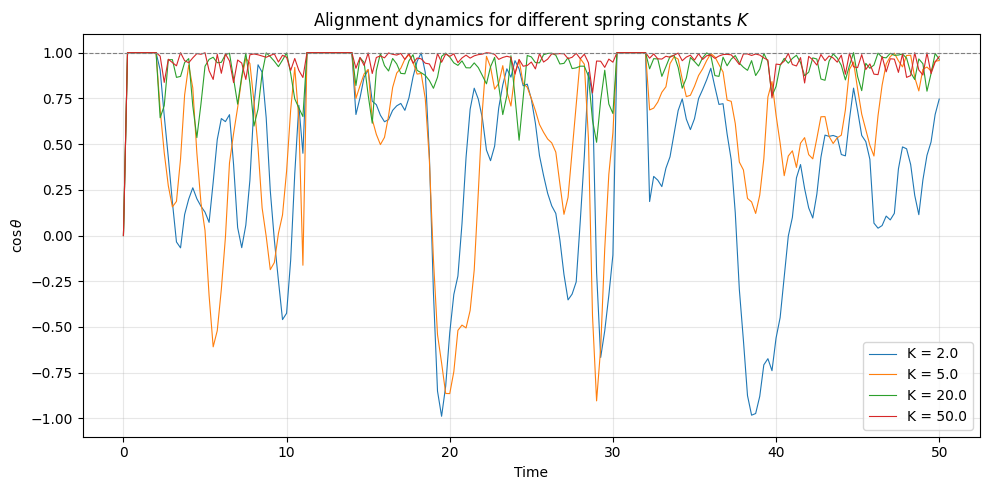

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

for K_val in K_values:
    t, ct = results[K_val]
    ax.plot(t, ct, lw=0.8, label=f"K = {K_val}")

ax.axhline(1.0, ls="--", color="gray", lw=0.8)
ax.set_xlabel("Time")
ax.set_ylabel(r"$\cos\theta$")
ax.set_title(r"Alignment dynamics for different spring constants $K$")
ax.legend(loc="lower right")
ax.set_ylim(-1.1, 1.1)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Validation

Quick sanity checks:
1. At equilibrium, the mean $\cos\theta$ should be close to 1 (within thermal noise)
2. Higher $K$ → tighter alignment (smaller variance)
3. Energy should be $U \approx kT/2$ at equilibrium (equipartition for one angular DOF)

In [9]:
print("=== Validation ===\n")

# Check that higher K gives tighter alignment
variances = {}
for K_val in K_values:
    _, ct = results[K_val]
    equil_ct = ct[len(ct) // 2 :]
    variances[K_val] = equil_ct.var()
    mean_ct = equil_ct.mean()
    print(f"K = {K_val:5.1f}:  ⟨cos θ⟩ = {mean_ct:.4f},  var = {variances[K_val]:.6f}")

print()

# Higher K should produce lower variance
prev_var = float("inf")
for K_val in sorted(K_values):
    assert variances[K_val] < prev_var or K_val == min(K_values), \
        f"Variance should decrease with K: K={K_val}"
    prev_var = variances[K_val]
print("✓ Variance decreases monotonically with increasing K")

# The strongest K should have mean cos θ > 0.9
strongest = max(K_values)
_, ct_strongest = results[strongest]
mean_strongest = ct_strongest[len(ct_strongest) // 2 :].mean()
assert mean_strongest > 0.9, f"Mean cos θ = {mean_strongest:.3f}, expected > 0.9 for K={strongest}"
print(f"✓ Mean cos θ = {mean_strongest:.4f} > 0.9 for K = {strongest}")

# Original long run: final cos θ should be near 1
assert cos_thetas[-1] > 0.8, f"Final cos θ = {cos_thetas[-1]:.3f}, expected > 0.8"
print(f"✓ Original run final cos θ = {cos_thetas[-1]:.4f} > 0.8")

print("\n=== All checks passed! The align_angle plugin works correctly. ===")

=== Validation ===

K =   2.0:  ⟨cos θ⟩ = 0.2778,  var = 0.248650
K =   5.0:  ⟨cos θ⟩ = 0.6512,  var = 0.117330
K =  20.0:  ⟨cos θ⟩ = 0.9248,  var = 0.007049
K =  50.0:  ⟨cos θ⟩ = 0.9576,  var = 0.002113

✓ Variance decreases monotonically with increasing K
✓ Mean cos θ = 0.9576 > 0.9 for K = 50.0
✓ Original run final cos θ = 0.8158 > 0.8

=== All checks passed! The align_angle plugin works correctly. ===
